# ⚡ Notebook 6 — Variance Risk Premium (VRP)
> Two implementations: **Short Straddle** and **Synthetic Variance Swap**

---

| Approach | Mechanism | Complexity |
|---|---|---|
| **Short Straddle** | Sell ATM call + put weekly | Simple |
| **Variance Swap** | 1/K² replication of log-contract | Advanced |

**Core thesis**: Implied volatility is systematically higher than realized volatility on equity indices.
Selling volatility earns the **variance risk premium** (VRP).

---
# Part 1 — Theory of the Variance Risk Premium
---

## 1.1 Definition

The **variance risk premium** is defined as:

$$\text{VRP}_t = \sigma^{\text{IV}}_t - \sigma^{\text{RV}}_{t+T}$$

Empirically on equity indices, $\mathbb{E}[\text{VRP}] > 0$:
options are systematically overpriced relative to realized volatility.

### Why does VRP exist?
- **Demand for insurance**: investors pay a premium to hedge tail risk
- **Jump risk**: options price jump risk not captured by diffusion models
- **Ambiguity aversion**: buyers pay extra for uncertainty about volatility itself
- **Institutional hedging**: systematic demand for puts keeps IV elevated

### Two estimators of realized volatility

| Estimator | Formula | Properties |
|---|---|---|
| **Close-to-Close** | $\hat{\sigma}_{cc} = \text{std}(\log R_t) \cdot \sqrt{252}$ | Simple, noisy |
| **Parkinson** | $\hat{\sigma}_{park} = \sqrt{\frac{252}{4\ln 2} \cdot \mathbb{E}[(\ln H/L)^2]}$ | 5x more efficient, uses range |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from src.data_loader import load_data
from src.plotting    import *
from src.metrics     import compute_metrics
from src.strategy_vrp import (
    build_short_straddle, build_variance_swap,
    compute_vrp_signal, compute_fair_variance_strike,
    realized_vol_cc, realized_vol_parkinson
)

#DATA_PATH = '../data/spy_simulated_2020_2022.csv'
DATA_PATH = '../data/spy_2020_2022.csv'  # real data

df = load_data(DATA_PATH)
print('Loaded:', df.shape)

✅  Loaded: ../data/spy_2020_2022.csv
    Rows            : 3,589,079
    Period          : 2020-01-02 → 2022-12-30
    Trading days    : 758
    Unique strikes  : 641
    Unique expiries : 514
Loaded: (3589079, 35)


## 1.2 VRP Signal Analysis


In [2]:
vrp = compute_vrp_signal(df, window=21)
print('VRP signal stats:')
print(vrp[['iv_atm','rv_cc','rv_park','vrp_cc','vrp_park']]
      .describe().round(4).to_string())
print()
print(f'VRP > 0 (cc)  : {(vrp.vrp_cc   > 0).mean():.1%} of days')
print(f'VRP > 0 (park): {(vrp.vrp_park > 0).mean():.1%} of days')

VRP signal stats:
         iv_atm     rv_cc   rv_park    vrp_cc  vrp_park
count  737.0000  737.0000  737.0000  737.0000  737.0000
mean     0.2068    0.2118    0.1269   -0.0051    0.0799
std      0.0892    0.1439    0.0858    0.0854    0.0496
min      0.0902    0.0650    0.0408   -0.5799   -0.1843
25%      0.1486    0.1291    0.0771   -0.0232    0.0526
50%      0.1934    0.1867    0.1115    0.0040    0.0776
75%      0.2434    0.2463    0.1487    0.0378    0.1038
max      0.7694    0.9616    0.5661    0.1680    0.3851

VRP > 0 (cc)  : 53.6% of days
VRP > 0 (park): 97.8% of days


/var/folders/1m/41txwqcx5qqf0h4zfvwssxr00000gn/T/ipykernel_62028/3364175513.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


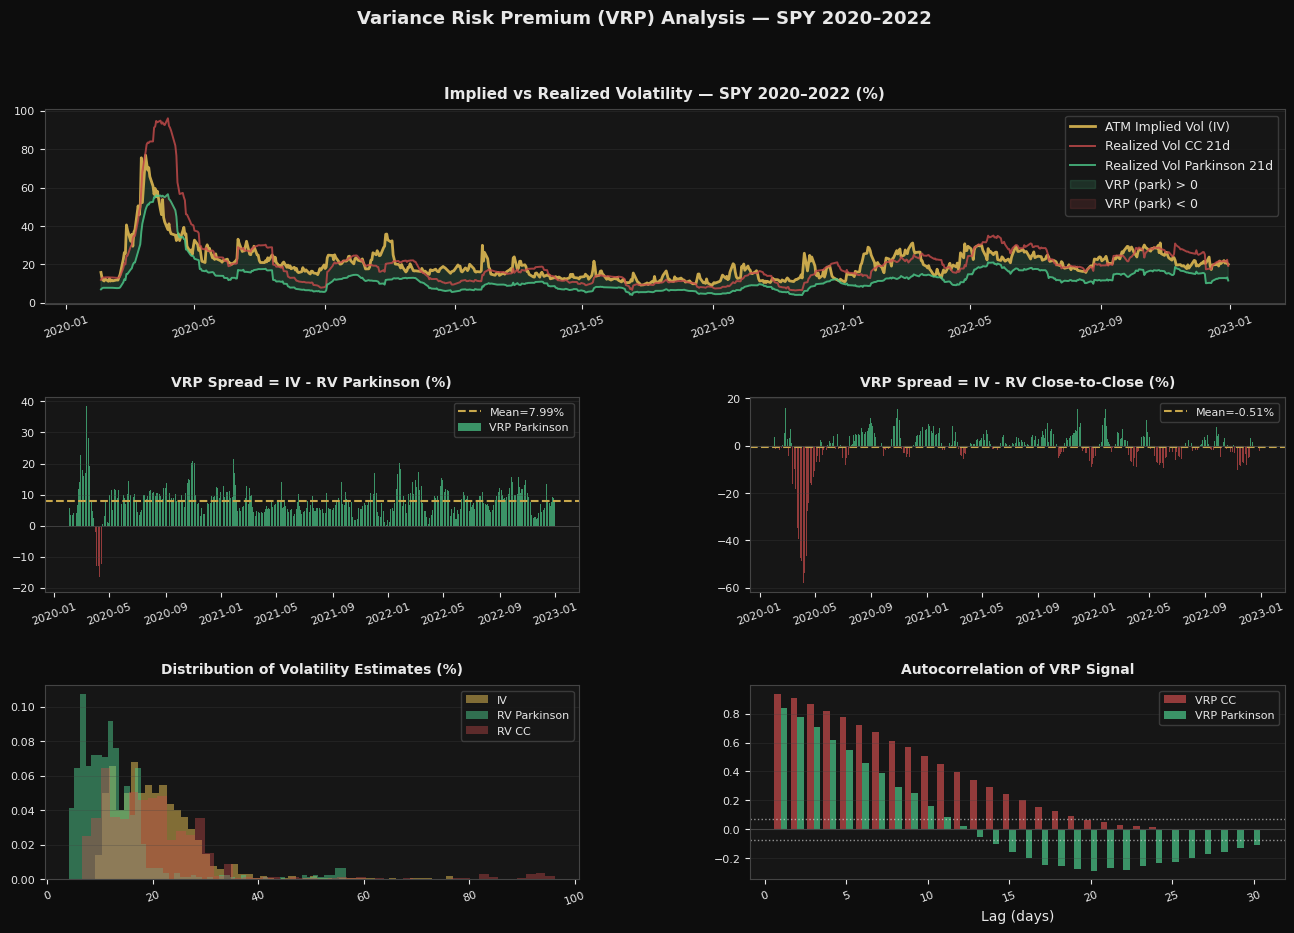

In [3]:
fig = plt.figure(figsize=(16, 10), facecolor=BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.32)

# Panel 1: IV vs RV over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(vrp.index, vrp['iv_atm']*100,   color=GOLD,   lw=2,   label='ATM Implied Vol (IV)')
ax1.plot(vrp.index, vrp['rv_cc']*100,    color=RED,    lw=1.4, label='Realized Vol CC 21d', alpha=0.8)
ax1.plot(vrp.index, vrp['rv_park']*100,  color=GREEN,  lw=1.4, label='Realized Vol Parkinson 21d', alpha=0.8)
ax1.fill_between(vrp.index, vrp['iv_atm']*100, vrp['rv_park']*100,
                 where=vrp['iv_atm'] >= vrp['rv_park'],
                 alpha=0.15, color=GREEN, label='VRP (park) > 0')
ax1.fill_between(vrp.index, vrp['iv_atm']*100, vrp['rv_park']*100,
                 where=vrp['iv_atm'] <  vrp['rv_park'],
                 alpha=0.15, color=RED, label='VRP (park) < 0')
style_ax(ax1, 'Implied vs Realized Volatility — SPY 2020–2022 (%)', fontsize=11)
legend(ax1, fontsize=9)

# Panel 2: VRP spread
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(vrp.index, vrp['vrp_park']*100,
        color=[GREEN if v > 0 else RED for v in vrp['vrp_park']],
        alpha=0.7, width=1, label='VRP Parkinson')
ax2.axhline(vrp['vrp_park'].mean()*100, color=GOLD, lw=1.5, ls='--',
            label=f'Mean={vrp["vrp_park"].mean()*100:.2f}%')
style_ax(ax2, 'VRP Spread = IV - RV Parkinson (%)')
legend(ax2)

# Panel 3: VRP CC spread
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(vrp.index, vrp['vrp_cc']*100,
        color=[GREEN if v > 0 else RED for v in vrp['vrp_cc']],
        alpha=0.7, width=1)
ax3.axhline(vrp['vrp_cc'].mean()*100, color=GOLD, lw=1.5, ls='--',
            label=f'Mean={vrp["vrp_cc"].mean()*100:.2f}%')
style_ax(ax3, 'VRP Spread = IV - RV Close-to-Close (%)')
legend(ax3)

# Panel 4: IV histogram
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(vrp['iv_atm']*100,   bins=50, color=GOLD,  alpha=0.6, label='IV', density=True)
ax4.hist(vrp['rv_park']*100,  bins=50, color=GREEN, alpha=0.5, label='RV Parkinson', density=True)
ax4.hist(vrp['rv_cc']*100,    bins=50, color=RED,   alpha=0.4, label='RV CC', density=True)
style_ax(ax4, 'Distribution of Volatility Estimates (%)')
legend(ax4)

# Panel 5: VRP autocorrelation
ax5 = fig.add_subplot(gs[2, 1])
lags = range(1, 31)
acf_cc   = [vrp['vrp_cc'].autocorr(lag=l)   for l in lags]
acf_park = [vrp['vrp_park'].autocorr(lag=l) for l in lags]
ax5.bar([l-0.2 for l in lags], acf_cc,   0.4, color=RED,  alpha=0.7, label='VRP CC')
ax5.bar([l+0.2 for l in lags], acf_park, 0.4, color=GREEN,alpha=0.7, label='VRP Parkinson')
ax5.axhline(0, color=GREY, lw=0.8)
ax5.axhline(1.96/np.sqrt(len(vrp)), color=WHITE, lw=1, ls=':', alpha=0.6)
ax5.axhline(-1.96/np.sqrt(len(vrp)), color=WHITE, lw=1, ls=':', alpha=0.6)
style_ax(ax5, 'Autocorrelation of VRP Signal')
ax5.set_xlabel('Lag (days)')
legend(ax5)

fig.suptitle('Variance Risk Premium (VRP) Analysis — SPY 2020–2022',
             color=WHITE, fontsize=13, fontweight='bold')
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('../outputs/vrp_signal_analysis.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

---
# Part 2 — Strategy A: Short Straddle
---

## 2.1 Mechanics

Sell **both** legs of the ATM straddle each week:

$$\Pi_{\text{short straddle}} = (c + p) - |S_T - K|$$

Profitable when $|S_T - K| < c + p$, i.e. when SPY moves **less than the implied move**.

**Greeks:** Δ≈0, Γ<<0, Θ>>0, ν<<0 — maximum short vega, maximum long theta.

This is the **mirror image** of the Long Straddle (notebook 04).

**Relationship to VRP**: The expected P&L of one short straddle cycle is:

$$\mathbb{E}[\Pi] \approx \text{Notional} \times (\sigma^{\text{IV}} - \sigma^{\text{RV}}) \times \sqrt{T}$$

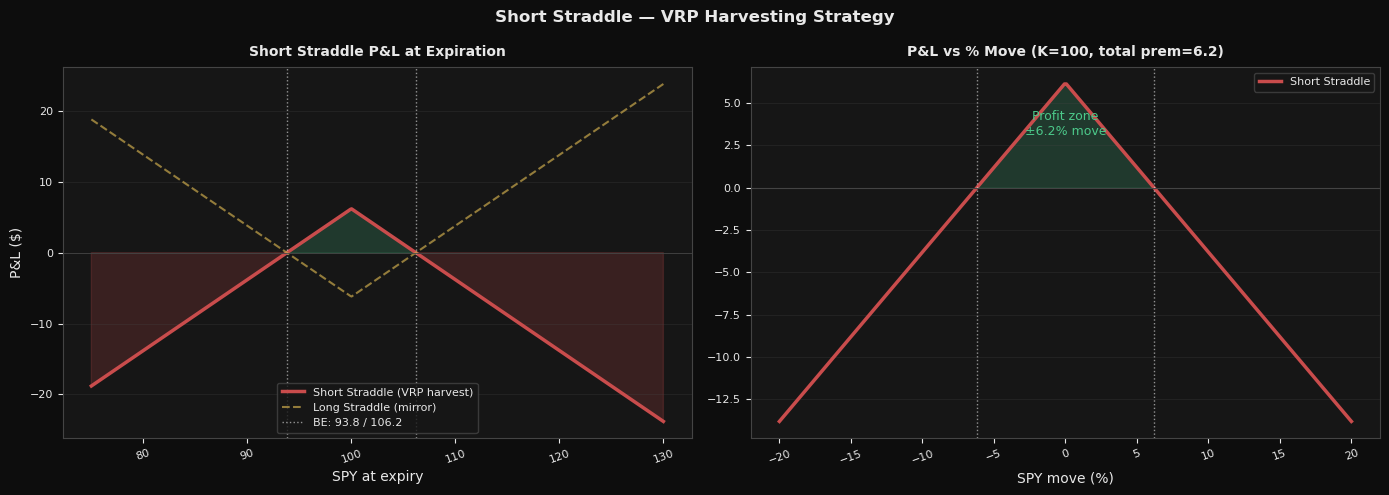

In [4]:
# Payoff diagrams for short straddle
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

K, c, p = 100, 3.2, 3.0
tot = c + p
ST  = np.linspace(75, 130, 500)

# Short straddle payoff
pnl_short = tot - np.abs(ST - K)
pnl_long  = np.abs(ST - K) - tot  # mirror

ax = axes[0]
ax.plot(ST, pnl_short, color=RED,  lw=2.5, label='Short Straddle (VRP harvest)')
ax.plot(ST, pnl_long,  color=GOLD, lw=1.5, ls='--', label='Long Straddle (mirror)', alpha=0.7)
ax.fill_between(ST, pnl_short, 0, where=pnl_short>0, alpha=0.2, color=GREEN)
ax.fill_between(ST, pnl_short, 0, where=pnl_short<0, alpha=0.2, color=RED)
ax.axvline(K-tot, color=WHITE, lw=1, ls=':', alpha=0.6, label=f'BE: {K-tot} / {K+tot}')
ax.axvline(K+tot, color=WHITE, lw=1, ls=':', alpha=0.6)
style_ax(ax, 'Short Straddle P&L at Expiration')
ax.set_xlabel('SPY at expiry'); ax.set_ylabel('P&L ($)')
legend(ax)

# Profit zone
ax2 = axes[1]
moves = np.linspace(-0.20, 0.20, 300) * 100
ax2.plot(moves, tot - np.abs(moves/100 * K), color=RED, lw=2.5, label='Short Straddle')
ax2.axhline(0, color=GREY, lw=0.8)
ax2.fill_between(moves, tot - np.abs(moves/100 * K), 0,
                 where=(tot - np.abs(moves/100 * K)) > 0, alpha=0.2, color=GREEN)
ax2.axvline(-(tot/K)*100, color=WHITE, lw=1, ls=':', alpha=0.6)
ax2.axvline( (tot/K)*100, color=WHITE, lw=1, ls=':', alpha=0.6)
ax2.annotate(f'Profit zone\n±{tot/K*100:.1f}% move',
             xy=(0, tot*0.5), ha='center', color=GREEN, fontsize=9)
style_ax(ax2, f'P&L vs % Move (K={K}, total prem={tot})')
ax2.set_xlabel('SPY move (%)')
legend(ax2)

fig.suptitle('Short Straddle — VRP Harvesting Strategy',
             color=WHITE, fontsize=12, fontweight='bold')
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

## 2.2 Backtest — Short Straddle


In [5]:
ss = build_short_straddle(df, target_dte=7)
ss[['spy_price','index_level','spy_bnh','strike','total_premium','call_iv']].head(15)

✅  Short Straddle (VRP) index built
    Days      : 758
    Rolls     : 113
    Avg prem  : 8.328


,spy_price,index_level,spy_bnh,strike,total_premium,call_iv
date,,,,,,
2020-01-02,324.87,100.000000,100.000000,325.0,3.305,0.08007
2020-01-03,322.43,80.484115,99.248930,325.0,3.305,0.08007
2020-01-06,323.68,108.472012,99.633700,325.0,3.305,0.08007
2020-01-07,322.74,111.043873,99.344353,325.0,3.305,0.08007
2020-01-08,324.39,127.231467,99.852249,325.0,3.305,0.08007
2020-01-09,326.59,133.282905,100.529443,325.0,3.305,0.08007
2020-01-10,325.64,180.635401,100.237018,325.5,3.410,0.09692
2020-01-13,327.92,173.222390,100.938837,325.5,3.410,0.09692
2020-01-14,327.42,184.114977,100.784929,325.5,3.410,0.09692


/var/folders/1m/41txwqcx5qqf0h4zfvwssxr00000gn/T/ipykernel_62028/20794419.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vrp_sig = vrp['vrp_park'].reindex(ss_ret.index).fillna(method='ffill')
/var/folders/1m/41txwqcx5qqf0h4zfvwssxr00000gn/T/ipykernel_62028/20794419.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


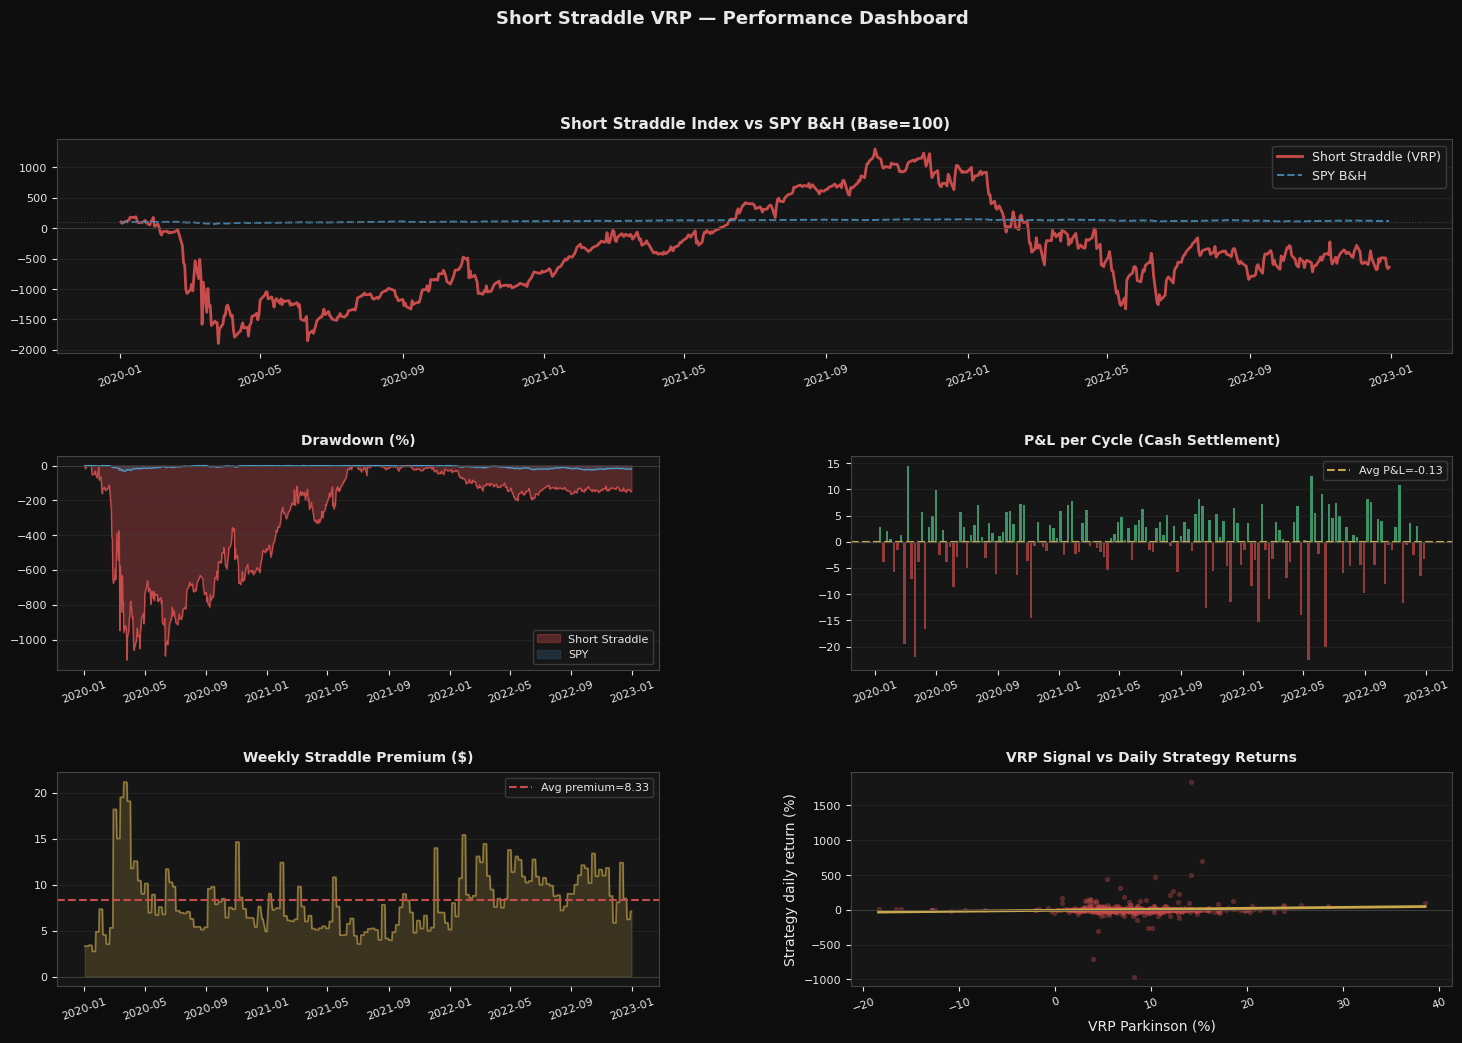

In [6]:
fig = plt.figure(figsize=(18, 11), facecolor=BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.32)

# Panel 1: Index vs SPY
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(ss.index, ss['index_level'], color=RED,  lw=2,   label='Short Straddle (VRP)')
ax1.plot(ss.index, ss['spy_bnh'],     color=BLUE, lw=1.4, label='SPY B&H', alpha=0.8, ls='--')
ax1.axhline(100, color=GREY, lw=0.8, ls=':')
style_ax(ax1, 'Short Straddle Index vs SPY B&H (Base=100)', fontsize=11)
legend(ax1, fontsize=9)

# Panel 2: Drawdown
ax2 = fig.add_subplot(gs[1, 0])
dd_ss  = (ss['index_level'] / ss['index_level'].cummax() - 1) * 100
dd_spy = (ss['spy_bnh']     / ss['spy_bnh'].cummax()     - 1) * 100
ax2.fill_between(ss.index, dd_ss,  0, color=RED,  alpha=0.35, label='Short Straddle')
ax2.fill_between(ss.index, dd_spy, 0, color=BLUE, alpha=0.18, label='SPY')
ax2.plot(ss.index, dd_ss,  color=RED,  lw=0.9)
ax2.plot(ss.index, dd_spy, color=BLUE, lw=0.9)
style_ax(ax2, 'Drawdown (%)')
legend(ax2)

# Panel 3: Rolling P&L per roll
ax3 = fig.add_subplot(gs[1, 1])
roll_pnl = ss['cash'].diff().dropna()
roll_pnl = roll_pnl[roll_pnl.abs() > 0.1]  # only roll days
colors_pnl = [GREEN if v > 0 else RED for v in roll_pnl]
ax3.bar(roll_pnl.index, roll_pnl, color=colors_pnl, alpha=0.7, width=5)
ax3.axhline(0, color=GREY, lw=0.8)
ax3.axhline(roll_pnl.mean(), color=GOLD, lw=1.5, ls='--',
            label=f'Avg P&L={roll_pnl.mean():.2f}')
style_ax(ax3, 'P&L per Cycle (Cash Settlement)')
legend(ax3)

# Panel 4: Premium collected over time
ax4 = fig.add_subplot(gs[2, 0])
prem = ss['total_premium'].dropna()
ax4.plot(prem.index, prem, color=GOLD, lw=1.2, alpha=0.6)
ax4.fill_between(prem.index, 0, prem, color=GOLD, alpha=0.2)
ax4.axhline(prem.mean(), color=RED, lw=1.5, ls='--',
            label=f'Avg premium={prem.mean():.2f}')
style_ax(ax4, 'Weekly Straddle Premium ($)')
legend(ax4)

# Panel 5: VRP signal vs strategy returns
ax5 = fig.add_subplot(gs[2, 1])
ss_ret  = ss['index_level'].pct_change().dropna()
vrp_sig = vrp['vrp_park'].reindex(ss_ret.index).fillna(method='ffill')
valid   = ~(ss_ret.isna() | vrp_sig.isna())
ax5.scatter(vrp_sig[valid]*100, ss_ret[valid]*100,
            color=RED, alpha=0.3, s=8)
z = np.polyfit(vrp_sig[valid], ss_ret[valid], 1)
xline = np.linspace(vrp_sig[valid].min(), vrp_sig[valid].max(), 100)
ax5.plot(xline*100, np.polyval(z, xline)*100, color=GOLD, lw=2)
style_ax(ax5, 'VRP Signal vs Daily Strategy Returns')
ax5.set_xlabel('VRP Parkinson (%)')
ax5.set_ylabel('Strategy daily return (%)')

fig.suptitle('Short Straddle VRP — Performance Dashboard',
             color=WHITE, fontsize=13, fontweight='bold', y=0.998)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('../outputs/vrp_short_straddle.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

---
# Part 3 — Strategy B: Synthetic Variance Swap
---

## 3.1 Theory — Log-Contract Replication

A **variance swap** pays the difference between realized and implied variance at expiration:

$$\Pi_{\text{var swap}} = N_{\text{var}} \times (\sigma^2_{\text{RV}} - K_{\text{var}})$$

where $K_{\text{var}}$ is the **fair variance strike** computed at inception.

### Replication via the log-contract (Demeterfi et al. 1999)

The fair variance strike is replicated by a static portfolio of OTM options:

$$K_{\text{var}} = \frac{2}{T} \left[
    \sum_{\text{puts}} \frac{\Delta K_i}{K_i^2} P(K_i)
  + \sum_{\text{calls}} \frac{\Delta K_i}{K_i^2} C(K_i)
\right]$$

This is exactly the **CBOE VIX² methodology** (with some adjustments).

### Short variance = VRP harvest

We **sell variance** at $K_{\text{var}}$ each month. If $\sigma^{\text{IV}} > \sigma^{\text{RV}}$ on average:

$$\mathbb{E}[\Pi_{\text{short var}}] = N_{\text{var}} \times (K_{\text{var}} - \mathbb{E}[\sigma^2_{\text{RV}}]) > 0$$

### Notional convention

We size by **vega notional** $N_{\nu}$ (\$ per 1 vol point):

$$N_{\text{var}} = \frac{N_{\nu}}{2 \cdot K_{\text{vol}}}$$

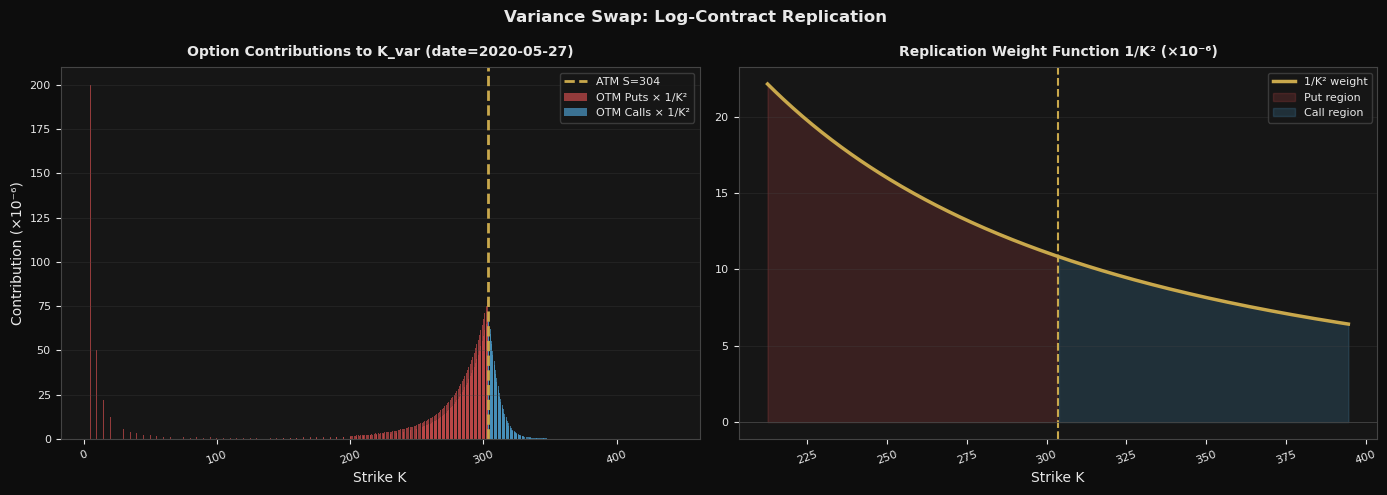

Fair Variance Strike  K_var = 0.119235
Fair Vol Strike       K_vol = 0.3453  (34.53%)
ATM Implied Vol              = 21.19%
Convexity adj (K_vol - IV)   = 13.337%


In [7]:
# Visualize the replication: option weights 1/K^2
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

# Get one day's chain for illustration
from src.data_loader import get_day
sample_date = sorted(df['QUOTE_DATE'].unique())[100]
df_day = get_day(df, sample_date)
S0 = df_day['UNDERLYING_LAST'].iloc[0]

# Find chain with DTE~22
chain = df_day.copy()
chain['_dd'] = (chain['DTE'] - 22).abs()
best = chain['_dd'].min()
chain = chain[chain['_dd'] == best].sort_values('STRIKE')

K = chain['STRIKE'].values
C = chain['C_MID'].values
P = chain['P_MID'].values

# Weight = 1/K^2
w = 1.0 / (K**2)

ax = axes[0]
ax.bar(K[K < S0], w[K < S0] * P[K < S0] * 1e6,
       color=RED, alpha=0.7, width=0.8, label='OTM Puts × 1/K²')
ax.bar(K[K >= S0], w[K >= S0] * C[K >= S0] * 1e6,
       color=BLUE, alpha=0.7, width=0.8, label='OTM Calls × 1/K²')
ax.axvline(S0, color=GOLD, lw=2, ls='--', label=f'ATM S={S0:.0f}')
style_ax(ax, f'Option Contributions to K_var (date={sample_date.date()})')
ax.set_xlabel('Strike K'); ax.set_ylabel('Contribution (×10⁻⁶)')
legend(ax)

# The 1/K^2 weight function
ax2 = axes[1]
K_range = np.linspace(S0 * 0.7, S0 * 1.3, 300)
ax2.plot(K_range, 1/(K_range**2) * 1e6, color=GOLD, lw=2.5, label='1/K² weight')
ax2.fill_between(K_range[K_range < S0], 0, 1/(K_range[K_range < S0]**2) * 1e6,
                 alpha=0.2, color=RED, label='Put region')
ax2.fill_between(K_range[K_range >= S0], 0, 1/(K_range[K_range >= S0]**2) * 1e6,
                 alpha=0.2, color=BLUE, label='Call region')
ax2.axvline(S0, color=GOLD, lw=1.5, ls='--')
style_ax(ax2, 'Replication Weight Function 1/K² (×10⁻⁶)')
ax2.set_xlabel('Strike K')
legend(ax2)

fig.suptitle('Variance Swap: Log-Contract Replication',
             color=WHITE, fontsize=12, fontweight='bold')
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

# Show K_var computation
vs_info = compute_fair_variance_strike(df_day, target_dte=22)
print(f'Fair Variance Strike  K_var = {vs_info["K_var"]:.6f}')
print(f'Fair Vol Strike       K_vol = {vs_info["K_vol"]:.4f}  ({vs_info["K_vol"]*100:.2f}%)')
print(f'ATM Implied Vol              = {vs_info["iv_atm"]*100:.2f}%')
print(f'Convexity adj (K_vol - IV)   = {(vs_info["K_vol"] - vs_info["iv_atm"])*100:.3f}%')

## 3.2 Backtest — Synthetic Variance Swap (Short)


In [8]:
vs = build_variance_swap(df, target_dte=22, notional_vega=1000, r=0.04)
vs[['spy_price','index_level','K_vol','rv_running','vrp_live','mtm_pnl']].head(15)

✅  Variance Swap (short variance) index built
    Days             : 758
    Avg K_vol (IV)   : 24.01%
    Avg RV (running) : 19.94%
    Avg VRP live     : 4.07%


,spy_price,index_level,K_vol,rv_running,vrp_live,mtm_pnl
date,,,,,,
2020-01-02,324.87,100.000000,0.117068,NaN,NaN,0.000000
2020-01-03,322.43,100.000000,0.117068,NaN,NaN,0.000000
2020-01-06,323.68,99.895396,0.117068,0.128059,-0.010990,-1.046036
2020-01-07,322.74,100.315005,0.117068,0.091084,0.025984,3.150054
2020-01-08,324.39,100.374609,0.117068,0.094239,0.022830,3.746092
2020-01-09,326.59,100.435158,0.117068,0.096031,0.021037,4.351578
2020-01-10,325.64,100.659953,0.117068,0.089662,0.027406,6.599535
2020-01-13,327.92,100.740042,0.117068,0.090881,0.026187,7.400419
2020-01-14,327.42,100.988971,0.117068,0.085657,0.031411,9.889709


/var/folders/1m/41txwqcx5qqf0h4zfvwssxr00000gn/T/ipykernel_62028/4134714821.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


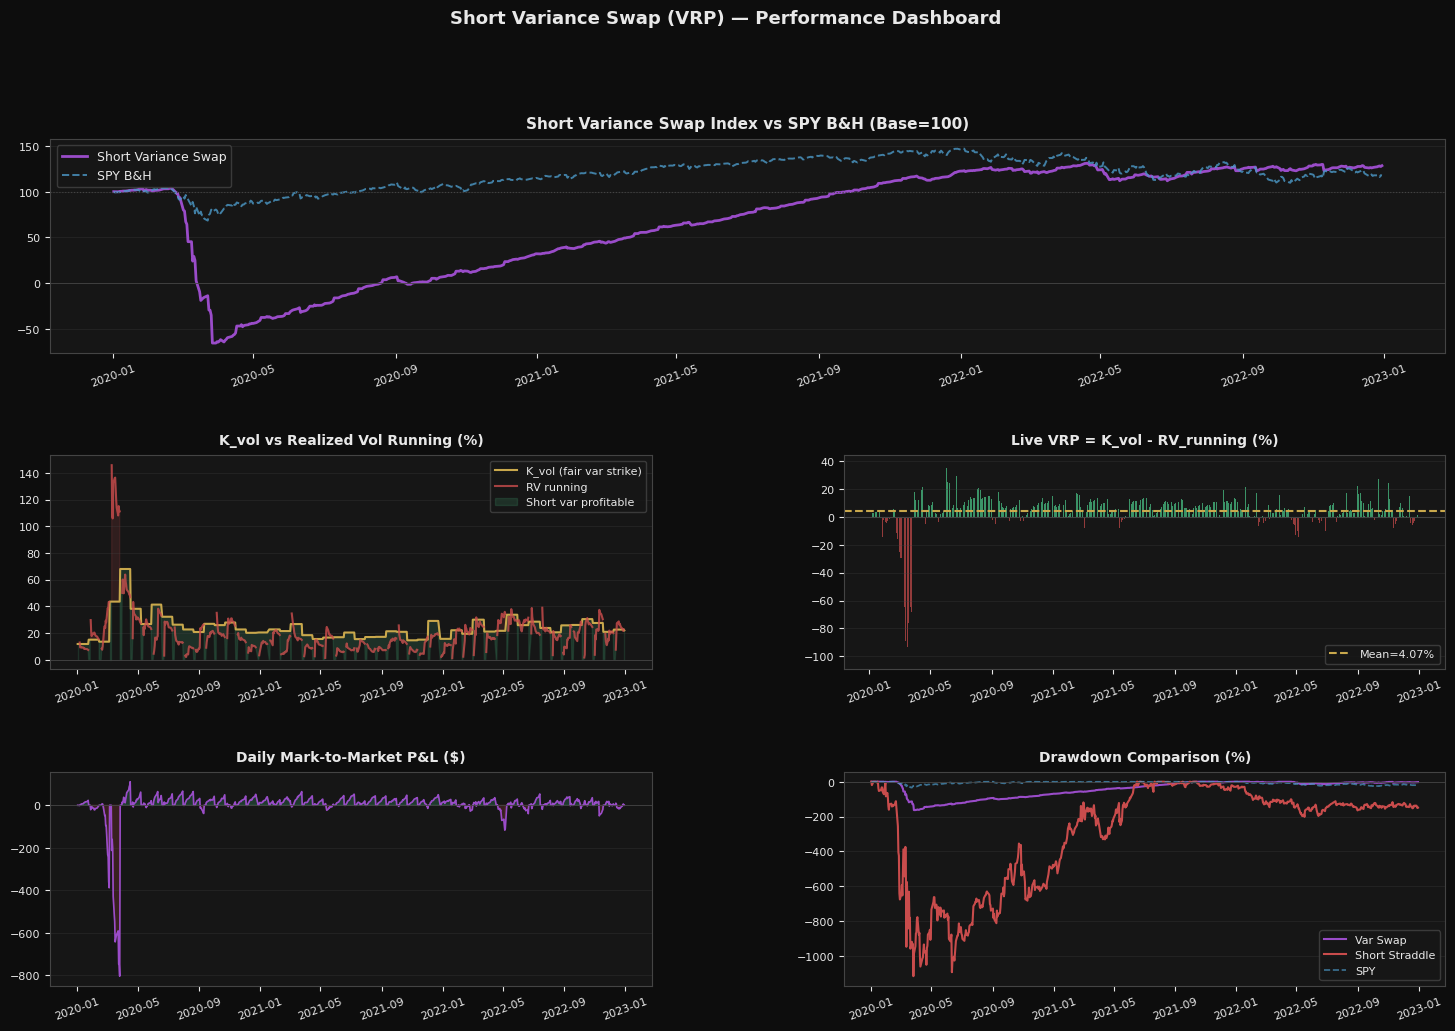

In [9]:
fig = plt.figure(figsize=(18, 11), facecolor=BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.32)

# Panel 1: Index
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(vs.index, vs['index_level'], color=PURPLE, lw=2,   label='Short Variance Swap')
ax1.plot(vs.index, vs['spy_bnh'],     color=BLUE,   lw=1.4, label='SPY B&H', alpha=0.8, ls='--')
ax1.axhline(100, color=GREY, lw=0.8, ls=':')
style_ax(ax1, 'Short Variance Swap Index vs SPY B&H (Base=100)', fontsize=11)
legend(ax1, fontsize=9)

# Panel 2: K_vol vs RV running
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(vs.index, vs['K_vol']*100,      color=GOLD,  lw=1.5, label='K_vol (fair var strike)')
ax2.plot(vs.index, vs['rv_running']*100, color=RED,   lw=1.5, label='RV running', alpha=0.8)
ax2.fill_between(vs.index,
    vs['K_vol'].fillna(0)*100, vs['rv_running'].fillna(0)*100,
    where=vs['K_vol'].fillna(0) >= vs['rv_running'].fillna(0),
    alpha=0.15, color=GREEN, label='Short var profitable')
ax2.fill_between(vs.index,
    vs['K_vol'].fillna(0)*100, vs['rv_running'].fillna(0)*100,
    where=vs['K_vol'].fillna(0) < vs['rv_running'].fillna(0),
    alpha=0.15, color=RED)
style_ax(ax2, 'K_vol vs Realized Vol Running (%)')
legend(ax2)

# Panel 3: Live VRP spread
ax3 = fig.add_subplot(gs[1, 1])
vrp_live = vs['vrp_live'].dropna()
ax3.bar(vrp_live.index,
        vrp_live * 100,
        color=[GREEN if v > 0 else RED for v in vrp_live],
        alpha=0.7, width=1)
ax3.axhline(0, color=GREY, lw=0.8)
ax3.axhline(vrp_live.mean()*100, color=GOLD, lw=1.5, ls='--',
            label=f'Mean={vrp_live.mean()*100:.2f}%')
style_ax(ax3, 'Live VRP = K_vol - RV_running (%)')
legend(ax3)

# Panel 4: MTM P&L
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(vs.index, vs['mtm_pnl'], color=PURPLE, lw=1.2)
ax4.fill_between(vs.index, 0, vs['mtm_pnl'],
                 where=vs['mtm_pnl'] >= 0, alpha=0.2, color=GREEN)
ax4.fill_between(vs.index, 0, vs['mtm_pnl'],
                 where=vs['mtm_pnl'] <  0, alpha=0.2, color=RED)
style_ax(ax4, 'Daily Mark-to-Market P&L ($)')

# Panel 5: Drawdown comparison
ax5 = fig.add_subplot(gs[2, 1])
dd_vs  = (vs['index_level'] / vs['index_level'].cummax() - 1) * 100
dd_ss  = (ss['index_level'] / ss['index_level'].cummax() - 1) * 100
dd_spy = (vs['spy_bnh']     / vs['spy_bnh'].cummax()     - 1) * 100
ax5.plot(vs.index, dd_vs,  color=PURPLE, lw=1.5, label='Var Swap')
ax5.plot(ss.index, dd_ss,  color=RED,    lw=1.5, label='Short Straddle')
ax5.plot(vs.index, dd_spy, color=BLUE,   lw=1.2, label='SPY', ls='--', alpha=0.7)
style_ax(ax5, 'Drawdown Comparison (%)')
legend(ax5)

fig.suptitle('Short Variance Swap (VRP) — Performance Dashboard',
             color=WHITE, fontsize=13, fontweight='bold', y=0.998)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('../outputs/vrp_variance_swap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

---
# Part 4 — Comparison: Short Straddle vs Variance Swap vs SPY
---

/var/folders/1m/41txwqcx5qqf0h4zfvwssxr00000gn/T/ipykernel_62028/2231902505.py:46: RuntimeWarning: invalid value encountered in scalar power
  ann  = (1+r).prod()**(252/n) - 1
/var/folders/1m/41txwqcx5qqf0h4zfvwssxr00000gn/T/ipykernel_62028/2231902505.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


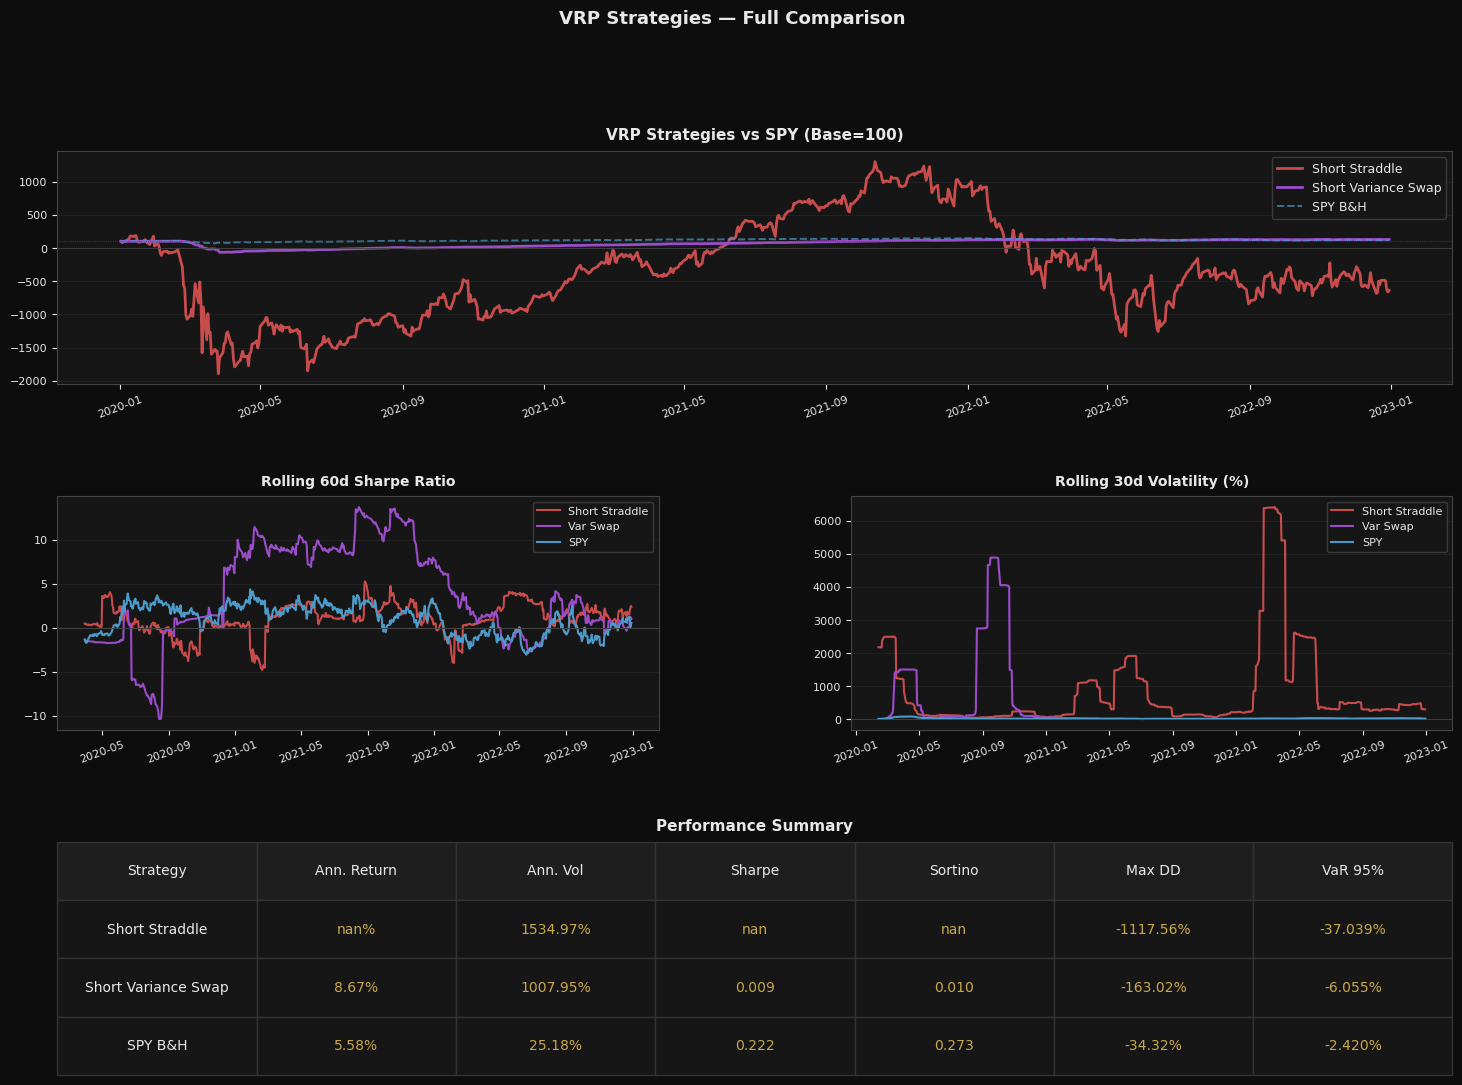

All VRP outputs saved to outputs/


In [10]:
fig = plt.figure(figsize=(18, 12), facecolor=BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.32)

# Panel 1: Index levels
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(ss.index, ss['index_level'], color=RED,    lw=2,   label='Short Straddle')
ax1.plot(vs.index, vs['index_level'], color=PURPLE, lw=2,   label='Short Variance Swap')
ax1.plot(vs.index, vs['spy_bnh'],     color=BLUE,   lw=1.4, label='SPY B&H', ls='--', alpha=0.7)
ax1.axhline(100, color=GREY, lw=0.6, ls=':')
style_ax(ax1, 'VRP Strategies vs SPY (Base=100)', fontsize=11)
legend(ax1, fontsize=9)

# Panel 2: Rolling Sharpe
ax2 = fig.add_subplot(gs[1, 0])
for ser, col, lbl in [
    (ss['index_level'], RED,    'Short Straddle'),
    (vs['index_level'], PURPLE, 'Var Swap'),
    (vs['spy_bnh'],     BLUE,   'SPY'),
]:
    r   = ser.pct_change().dropna()
    sh  = r.rolling(60).mean() / r.rolling(60).std() * np.sqrt(252)
    ax2.plot(sh.index, sh, color=col, lw=1.5, label=lbl)
ax2.axhline(0, color=GREY, lw=0.8)
style_ax(ax2, 'Rolling 60d Sharpe Ratio')
legend(ax2)

# Panel 3: Rolling vol
ax3 = fig.add_subplot(gs[1, 1])
for ser, col, lbl in [
    (ss['index_level'], RED,    'Short Straddle'),
    (vs['index_level'], PURPLE, 'Var Swap'),
    (vs['spy_bnh'],     BLUE,   'SPY'),
]:
    vol = ser.pct_change().rolling(30).std() * np.sqrt(252) * 100
    ax3.plot(vol.index, vol, color=col, lw=1.5, label=lbl)
style_ax(ax3, 'Rolling 30d Volatility (%)')
legend(ax3)

# Panel 4: Metrics
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off'); ax4.set_facecolor(PANEL)

def get_metrics_row(ser, name):
    r    = ser.pct_change().dropna()
    n    = len(r)
    ann  = (1+r).prod()**(252/n) - 1
    vol  = r.std() * np.sqrt(252)
    sh   = ann / vol if vol > 0 else np.nan
    mdd  = ((ser / ser.cummax()) - 1).min()
    down = r[r<0].std() * np.sqrt(252)
    sor  = ann / down if down > 0 else np.nan
    var95 = np.percentile(r, 5)
    return [name, f'{ann:.2%}', f'{vol:.2%}', f'{sh:.3f}',
            f'{sor:.3f}', f'{mdd:.2%}', f'{var95:.3%}']

rows = [
    get_metrics_row(ss['index_level'], 'Short Straddle'),
    get_metrics_row(vs['index_level'], 'Short Variance Swap'),
    get_metrics_row(vs['spy_bnh'],     'SPY B&H'),
]
cols = ['Strategy', 'Ann. Return', 'Ann. Vol', 'Sharpe', 'Sortino', 'Max DD', 'VaR 95%']
tbl  = ax4.table(cellText=rows, colLabels=cols,
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1e1e1e' if r==0 else PANEL)
    cell.set_edgecolor('#333')
    cell.set_text_props(color=GOLD if (r>0 and c>0) else WHITE)
ax4.set_title('Performance Summary', color=WHITE, fontsize=11, fontweight='bold', pad=8)

fig.suptitle('VRP Strategies — Full Comparison',
             color=WHITE, fontsize=13, fontweight='bold', y=0.998)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('../outputs/vrp_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('All VRP outputs saved to outputs/')